In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
from sklearn.model_selection import (train_test_split,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                    )
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from typing import cast
from sklearn.utils import Bunch
from sklearn.metrics import (classification_report,
                             f1_score,
                             accuracy_score,
                             recall_score,
                             confusion_matrix
                             )
from sklearn.preprocessing import StandardScaler

In [110]:
Age = np.random.randint(18,101,10000)
Salary = np.random.randint(10000,50000,10000)

df = pd.DataFrame(
    {"Age":Age,
     "Salary":Salary}
)
df["churn"] = np.where(((df["Age"] >= 20) & (df["Age"] <= 30)) | (df["Salary"] > 25000),
                       1,
                       0)
X = df.drop(columns="churn")
y = df["churn"]
np.bincount(y)


array([3297, 6703])

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",KNeighborsClassifier())
])


param_grid = {
    "knn__n_neighbors":range(1,10),
    "knn__weights":["uniform", "distance"],
    "knn__metric":["euclidean", "manhattan"],
}


grid = GridSearchCV(estimator=pipeline,
                   param_grid=param_grid,
                   cv = 5, 
                   scoring="accuracy",
                   n_jobs= -1)


grid.fit(X_train, y_train)
model = grid.best_estimator_

y_pred = model.predict(X_test)
cm  = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       659
           1       1.00      1.00      1.00      1341

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



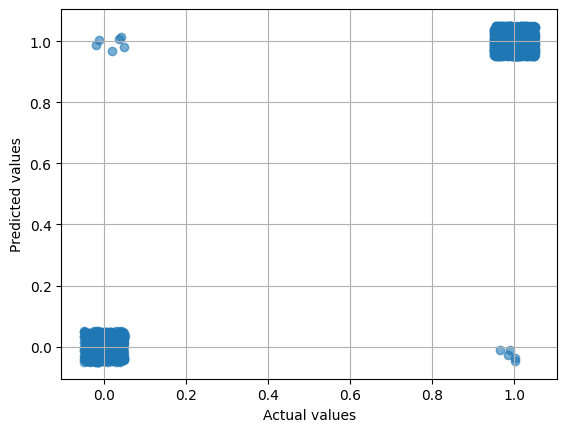

In [118]:
plt.scatter(y_test + np.random.uniform(-0.05, 0.05, size=len(y_test)),
            y_pred + np.random.uniform(-0.05, 0.05, size=len(y_pred)),
            alpha=0.6)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.grid(True)
plt.show()


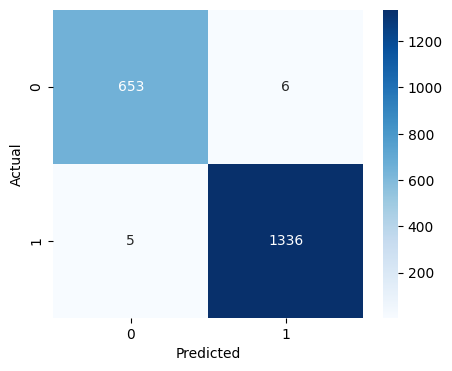

In [119]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()